In [104]:
import sklearn.datasets as datasets

iris = datasets.load_iris()

In [105]:
import pandas as pd

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


<Axes: >

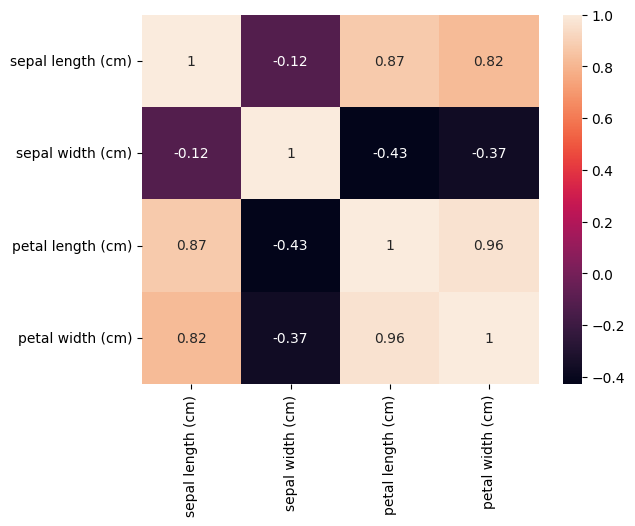

In [107]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True)

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

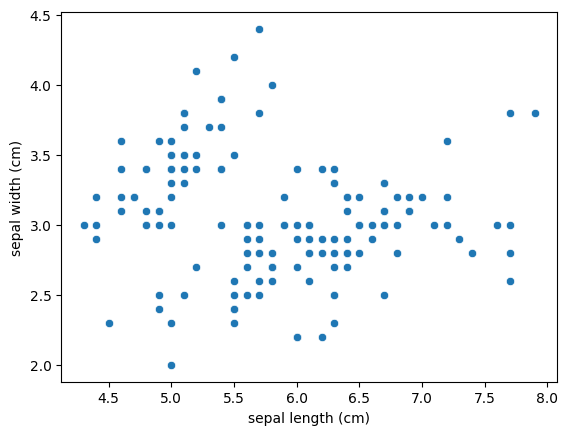

In [108]:
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', data=df)

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

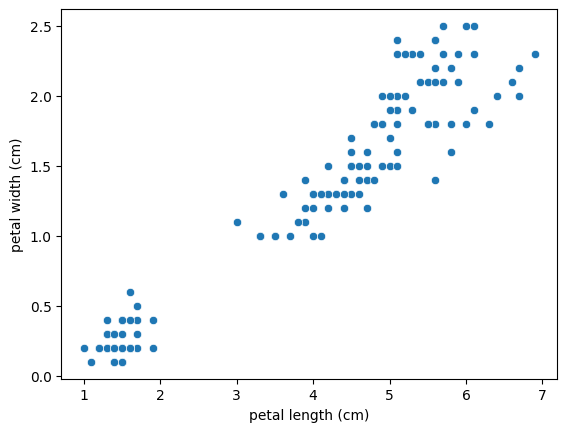

In [109]:
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', data=df)

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

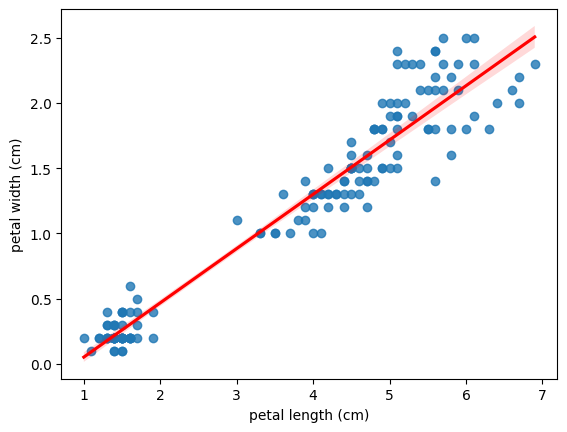

In [110]:
sns.regplot(x='petal length (cm)', y='petal width (cm)', data=df,
            line_kws={"color": "red"}, )

In [111]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df.drop('petal width (cm)', axis=1)
y = df['petal width (cm)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [112]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 0.04633260332576447
R-squared: 0.9271105193357898


In [113]:
!pip install fpdf reportlab -q

In [114]:
from reportlab.lib.pagesizes import letter
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                 Image, PageBreak, Table, TableStyle)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from reportlab.lib.units import inch


In [115]:
nombre_pdf = "reporte iris.pdf"

pdf = SimpleDocTemplate(nombre_pdf, pagesize=letter)

styles = getSampleStyleSheet()

titulo_style   = ParagraphStyle("Titulo",  parent=styles["Title"],   fontSize=16, spaceAfter=12)
h1_style       = ParagraphStyle("H1",      parent=styles["Heading1"], fontSize=13, spaceAfter=6)
h2_style       = ParagraphStyle("H2",      parent=styles["Heading2"], fontSize=11, spaceAfter=4)
body_style     = ParagraphStyle("Body",    parent=styles["Normal"],  fontSize=10, leading=14, spaceAfter=6)
pregunta_style = ParagraphStyle("Preg",    parent=styles["Normal"],  fontSize=10, leading=14,
                                 textColor=colors.darkblue, fontName="Helvetica-Bold", spaceAfter=3)
respuesta_style= ParagraphStyle("Resp",    parent=styles["Normal"],  fontSize=10, leading=14,
                                 leftIndent=15, spaceAfter=8)

story = []

story.append(Paragraph("Reporte de Resultados", titulo_style))
story.append(Spacer(1, 12))


### 1. **Introducción al Reporte**

In [116]:
# Introducción al Reporte
story.append(Paragraph("Análisis del Conjunto de Datos Iris y Modelado de Regresión", h1_style))
story.append(Paragraph("Este reporte detalla un análisis exploratorio y la implementación de un modelo de regresión lineal para predecir el 'ancho del pétalo' (petal width) utilizando el clásico conjunto de datos Iris. El objetivo es demostrar el proceso de carga de datos, exploración, visualización y desarrollo de un modelo predictivo, justificando las decisiones tomadas en cada etapa.", body_style))
story.append(Spacer(1, 12))

### 2. **Carga y Exploración de Datos**

In [117]:
import io
from contextlib import redirect_stdout
from reportlab.platypus import Table, TableStyle
from reportlab.lib import colors

# Sección: Carga y Exploración de Datos
story.append(Paragraph("Carga y Exploración Inicial de Datos", h1_style))
story.append(Paragraph("El conjunto de datos Iris es cargado usando `sklearn.datasets`. Posteriormente, se convierte en un DataFrame de Pandas para facilitar la manipulación y el análisis. Se realiza una inspección inicial para entender la estructura de los datos y verificar la presencia de valores nulos.", body_style))
story.append(Spacer(1, 6))

# df.head()
story.append(Paragraph("Primeras 5 filas del DataFrame:", h2_style))

# Convertir df.head() a un formato de tabla para ReportLab
data_head = [df.columns.tolist()] + df.head().values.tolist()
table_style = TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
    ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
    ('GRID', (0, 0), (-1, -1), 1, colors.black)
])

table = Table(data_head)
table.setStyle(table_style)
story.append(table)
story.append(Spacer(1, 6))

# df.info()
story.append(Paragraph("Información general del DataFrame:", h2_style))

# Capturar la salida de df.info() para incluirla como texto
f = io.StringIO()
with redirect_stdout(f):
    df.info()
s = f.getvalue()

story.append(Paragraph(f'<font face="Courier">{s.replace("\n", "<br/>")}</font>', body_style)) # Usar <br/> para saltos de línea y Courier para monoespacio
story.append(Spacer(1, 6))

story.append(Paragraph("Decisión y Hallazgos: La inspección inicial confirma que el dataset no tiene valores nulos y que todas las características numéricas están en el formato `float64`, lo cual es adecuado para el modelado. Las primeras filas nos dan una idea de los rangos de valores para cada característica.", body_style))
story.append(Spacer(1, 12))

### 3. **Visualizaciones de Datos**

In [118]:
# Sección: Visualizaciones
import matplotlib.pyplot as plt

story.append(Paragraph("Visualizaciones de Datos", h1_style))
story.append(Paragraph("Se generaron varias visualizaciones para entender las relaciones entre las variables. Una de las más relevantes es la relación entre la longitud y el ancho del pétalo, mostrando una clara tendencia lineal. Esta visualización justifica el uso de un modelo de regresión lineal.", body_style))
story.append(Spacer(1, 6))

# Guardar el gráfico sns.regplot como imagen
plt.figure(figsize=(8, 5))
sns.regplot(x='petal length (cm)', y='petal width (cm)', data=df, line_kws={"color": "red"})
plt.title('Relación entre Longitud y Ancho del Pétalo con Línea de Regresión')
plt.xlabel('Longitud del Pétalo (cm)')
plt.ylabel('Ancho del Pétalo (cm)')
plt.grid(True, linestyle='--', alpha=0.7)

# Guardar la figura en un archivo temporal
img_filename = '/content/regplot_petal_length_width.png' # Usar ruta absoluta
plt.savefig(img_filename, bbox_inches='tight')
plt.close() # Cierra la figura para no mostrarla en el notebook si no es deseado

# Añadir la imagen al PDF
story.append(Image(img_filename, width=400, height=250))
story.append(Paragraph("Figura 1: Diagrama de dispersión mostrando la relación lineal entre la longitud y el ancho del pétalo, con la línea de regresión lineal superpuesta. Esta visualización respalda la elección de un modelo de regresión lineal para predecir el ancho del pétalo.", body_style))
story.append(Spacer(1, 12))

# Puedes agregar más visualizaciones aquí siguiendo el mismo patrón


### 4. **Resultados del Modelo de Regresión Lineal**

In [119]:
# Sección: Resultados del Modelo
story.append(Paragraph("Resultados del Modelo de Regresión Lineal", h1_style))
story.append(Paragraph("Se implementó un modelo de regresión lineal para predecir el 'ancho del pétalo' (`petal width (cm)`). El modelo fue entrenado con un 80% de los datos y evaluado en el 20% restante. A continuación, se presentan las métricas de rendimiento clave: Mean Squared Error (MSE) y R-squared.", body_style))
story.append(Spacer(1, 6))

# Muestra los resultados de MSE y R-squared que ya calculaste
story.append(Paragraph(f'Mean Squared Error (MSE): {mse:.3f}', h2_style))
story.append(Paragraph(f'R-squared: {r2:.3f}', h2_style))
story.append(Spacer(1, 6))

story.append(Paragraph(f"Análisis de Resultados: Un valor de MSE de \\( \\mathbf{{{mse:.3f}}} \\) indica que, en promedio, las predicciones del modelo se desvían de los valores reales por una cantidad relativamente pequeña, lo que sugiere un buen ajuste. El coeficiente de determinación \\( \\mathbf{{R^2}} \\) de \\( \\mathbf{{{r2:.3f}}} \\) significa que aproximadamente el {r2*100:.1f}% de la varianza en el ancho del pétalo es explicada por las características predictoras en nuestro modelo, lo cual es un indicador de un modelo con un poder predictivo considerable.", body_style))
story.append(Spacer(1, 12))

### 5. **Conclusiones**

In [120]:
# Sección: Conclusiones
story.append(Paragraph("Conclusiones", titulo_style))
story.append(Paragraph("El modelo de regresión lineal desarrollado ha demostrado ser efectivo para predecir el ancho del pétalo en el conjunto de datos Iris, basándose en la fuerte relación lineal observada entre las características. Los resultados obtenidos con un MSE bajo y un R-squared alto sugieren que el modelo tiene un buen rendimiento predictivo.", body_style))
story.append(Paragraph("Este reporte sirve como una demostración de un flujo de trabajo típico en ciencia de datos, desde la exploración inicial hasta el modelado y la evaluación, justificando cada paso con datos y visualizaciones.", body_style))
story.append(Spacer(1, 12))

### 6. **Generar el Documento PDF**

Finalmente, usamos `pdf.build(story)` para crear el archivo PDF con todo el contenido que hemos añadido a la lista `story`.

In [121]:
# Generar el PDF
pdf.build(story)
print(f"El reporte '{nombre_pdf}' ha sido generado exitosamente.")

# Si estás en Google Colab y quieres descargarlo fácilmente, puedes usar:
from google.colab import files
files.download(nombre_pdf)

El reporte 'reporte iris.pdf' ha sido generado exitosamente.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>